# Mango Classifier with MobileNetV2


Gi-load niini ang mga Python library nga gigamit sa notebook, apil ang TensorFlow/Keras para sa training, NumPy para sa array operations, Matplotlib para sa mga graph, ug MobileNetV2 preprocessing tools.

In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


Giset anhi ang random seed aron mahimong reproducible ang resulta, gidefine ang training settings sama sa image size, batch size, learning rate, ug epochs, dayon gipangita ang dataset folders para sa train ug test images.

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CONFIG = {
    "dataset_path": "dataset",
    "model_name": "mango_classifier",
    "img_size": (224, 224),
    "batch_size": 16, 
    "head_epochs": 15,
    "fine_tune_epochs": 10,
    "head_learning_rate": 1e-3,
    "fine_tune_learning_rate": 1e-5,
    "dropout_rate": 0.3,
    "fine_tune_last_n_layers": 30,
    "validation_split": 0.2,
}

cwd = Path.cwd()

if (cwd / CONFIG["dataset_path"]).exists():
    BASE_DIR = cwd
else:
    BASE_DIR = cwd.parent

dataset_path = BASE_DIR / CONFIG["dataset_path"]
train_path = dataset_path / "train"
test_path = dataset_path / "test"

print("Base directory:", BASE_DIR)
print("Train path:", train_path)
print("Test path:", test_path)

assert train_path.exists(), f"Missing train folder: {train_path}"
assert test_path.exists(), f"Missing test folder: {test_path}"

train_classes = sorted([p.name for p in train_path.iterdir() if p.is_dir()])
test_classes = sorted([p.name for p in test_path.iterdir() if p.is_dir()])

assert train_classes == test_classes, "Train and test class folders do not match."

print("Number of classes:", len(train_classes))
print("Classes:", train_classes)

Base directory: c:\Fruit Mango Classifier
Train path: c:\Fruit Mango Classifier\dataset\train
Test path: c:\Fruit Mango Classifier\dataset\test
Number of classes: 5
Classes: ['Amrapali', 'Fazlee', 'Harivanga', 'Mollika', 'Nilambori']


Giihap dinhi kung pila ka images ang naa sa matag mango class sa train ug test folders aron makumpirma nga balanse ang dataset ug husto ang pagka-organize niini.

In [3]:
class_counts = []

for cls in train_classes:
    train_count = len([p for p in (train_path / cls).iterdir() if p.is_file()])
    test_count = len([p for p in (test_path / cls).iterdir() if p.is_file()])
    class_counts.append((cls, train_count, test_count))

for cls, train_count, test_count in class_counts:
    print(f"{cls:25s} train: {train_count:4d} | test: {test_count:4d}")

total_train = sum(x[1] for x in class_counts)
total_test = sum(x[2] for x in class_counts)

print("\nTotal train images:", total_train)
print("Total test images:", total_test)
print("Approx train images/class:", round(total_train / max(len(train_classes), 1), 2))

Amrapali                  train:  492 | test:  140
Fazlee                    train:  492 | test:  140
Harivanga                 train:  487 | test:  140
Mollika                   train:  499 | test:  140
Nilambori                 train:  499 | test:  140

Total train images: 2469
Total test images: 700
Approx train images/class: 493.8


Gihimo dinhi ang training, validation, ug test data loaders. Kini nga block nag-apply usab og image preprocessing ug augmentation, dayon mobasa sa images gikan sa mga folder by batch.

In [4]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=CONFIG["validation_split"],
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode="nearest"
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=CONFIG["validation_split"]
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=CONFIG["img_size"],
    batch_size=CONFIG["batch_size"],
    subset="training",
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_data = val_gen.flow_from_directory(
    train_path,
    target_size=CONFIG["img_size"],
    batch_size=CONFIG["batch_size"],
    subset="validation",
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=CONFIG["img_size"],
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    shuffle=False
)

print("Train classes:", train_data.num_classes)
print("Train samples:", train_data.samples)
print("Val samples:", val_data.samples)
print("Test samples:", test_data.samples)
print("Class indices:", train_data.class_indices)

assert train_data.class_indices == test_data.class_indices, "Train/test class indices do not match." 

Found 1978 images belonging to 5 classes.
Found 491 images belonging to 5 classes.
Found 700 images belonging to 5 classes.
Train classes: 5
Train samples: 1978
Val samples: 491
Test samples: 700
Class indices: {'Amrapali': 0, 'Fazlee': 1, 'Harivanga': 2, 'Mollika': 3, 'Nilambori': 4}


Naghimo kini og label map tali sa numeric class IDs ug mango class names, dayon gi-save ang mapping sa `class_indices.json` para magamit unya sa prediction.

In [5]:
idx_to_class = {v: k for k, v in train_data.class_indices.items()}

with open("class_indices.json", "w") as f:
    json.dump(train_data.class_indices, f, indent=2)

print(idx_to_class)

{0: 'Amrapali', 1: 'Fazlee', 2: 'Harivanga', 3: 'Mollika', 4: 'Nilambori'}


Nagpakita kini og pipila ka sample training images uban sa ilang labels aron makita nimo kung sakto ba ang pagka-load sa dataset.

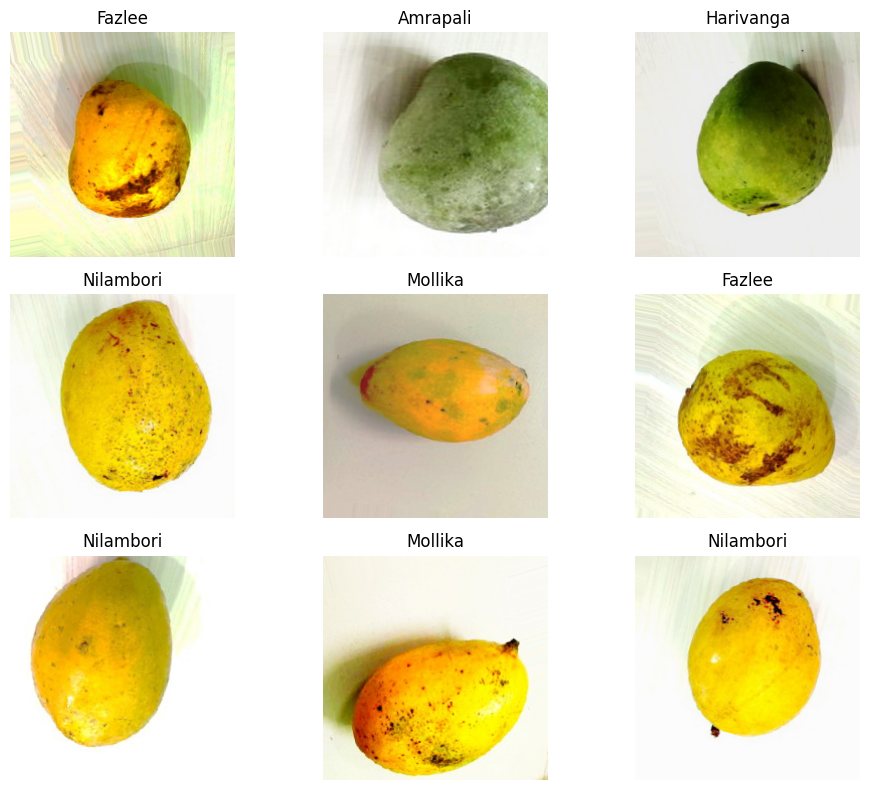

In [6]:
images, labels = next(train_data)

plt.figure(figsize=(10, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    display_img = (images[i] + 1) / 2
    plt.imshow(np.clip(display_img, 0, 1))
    plt.title(idx_to_class[int(np.argmax(labels[i]))])
    plt.axis("off")
plt.tight_layout()
plt.show()

Naghimo kini sa transfer learning model gamit ang MobileNetV2 isip feature extractor, midugang sa classification head, ug gi-compile ang model para sa training.

In [7]:
base = MobileNetV2(
    input_shape=CONFIG["img_size"] + (3,),
    include_top=False,
    weights="imagenet"
)

base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(CONFIG["dropout_rate"]),
    layers.Dense(train_data.num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG["head_learning_rate"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Gidefine dinhi ang helper callbacks sama sa early stopping, learning rate reduction, ug pag-save sa best-model checkpoint aron mas stable ang training.

In [8]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "best_mango_classifier.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

Gitrain lang dinhi ang bag-ong gidugang nga classification head samtang naka-freeze gihapon ang MobileNetV2 base.

In [9]:
history_head = model.fit(
    train_data,
    validation_data=val_data,
    epochs=CONFIG["head_epochs"],
    callbacks=callbacks
)

Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.5818 - loss: 1.0464
Epoch 1: val_loss improved from None to 0.42650, saving model to best_mango_classifier.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.7472 - loss: 0.6937 - val_accuracy: 0.8513 - val_loss: 0.4265 - learning_rate: 0.0010
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.8927 - loss: 0.3231
Epoch 2: val_loss improved from 0.42650 to 0.42025, saving model to best_mango_classifier.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 114s 913ms/step - accuracy: 0.9171 - loss: 0.2651 - val_accuracy: 0.8513 - val_loss: 0.4202 - learning_rate: 0.0010
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.9509 - loss: 0.1887
Epoch 3: val_loss improved from 0.42025 to 0.27958, saving model to best_mango_classifier.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 110s 887ms/step - accuracy: 0.9570 - loss: 0.1713 - val_accuracy: 0.8941 - val_loss: 0.2796 - learning_rate: 0.0010
Epoch 4/15
124/124 

Nag-plot kini sa training ug validation accuracy/loss para sa unang training phase aron makita kung unsa kaayo ang pagkat-on sa model.

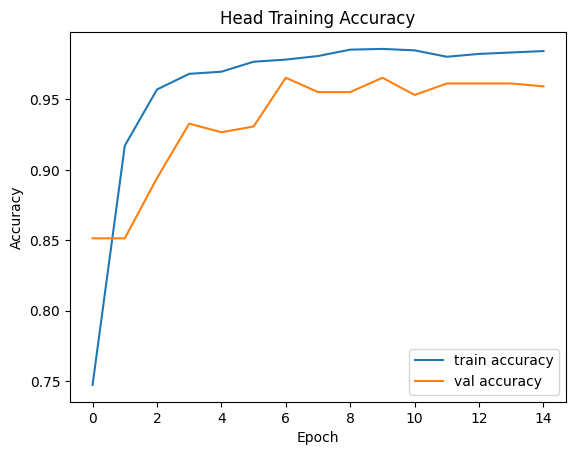

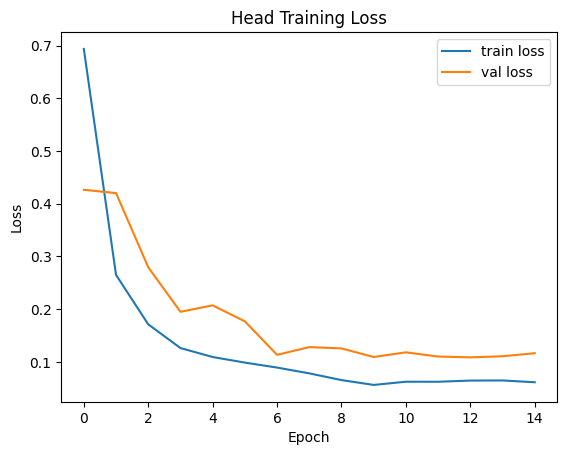

In [10]:
def plot_history(history, title_prefix=""):
    plt.figure()
    plt.plot(history.history["accuracy"], label="train accuracy")
    plt.plot(history.history["val_accuracy"], label="val accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_head, "Head Training")

Gi-unfreeze dinhi ang usa ka bahin sa MobileNetV2 base model ug gi-recompile pag-usab ang network gamit ang mas gamay nga learning rate para sa fine-tuning.

In [11]:
base.trainable = True

for layer in base.layers[:-CONFIG["fine_tune_last_n_layers"]]:
    layer.trainable = False

for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG["fine_tune_learning_rate"]),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,517,125 (5.79 MB)

 Non-trainable params: 747,264 (2.85 MB)

# Fine-Tuning nga Training
Gipadagan dinhi ang ikaduhang training phase aron ang model backbone mas makaangay pag-ayo sa mango dataset.

In [12]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=CONFIG["fine_tune_epochs"],
    callbacks=callbacks
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.9841 - loss: 0.0584
Epoch 1: val_loss did not improve from 0.10867
124/124 ━━━━━━━━━━━━━━━━━━━━ 106s 787ms/step - accuracy: 0.9858 - loss: 0.0487 - val_accuracy: 0.9532 - val_loss: 0.1339 - learning_rate: 1.0000e-05
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.9914 - loss: 0.0229
Epoch 2: val_loss improved from 0.10867 to 0.05944, saving model to best_mango_classifier.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 101s 811ms/step - accuracy: 0.9919 - loss: 0.0237 - val_accuracy: 0.9796 - val_loss: 0.0594 - learning_rate: 1.0000e-05
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9978 - loss: 0.0129
Epoch 3: val_loss did not improve from 0.05944
124/124 ━━━━━━━━━━━━━━━━━━━━ 98s 790ms/step - accuracy: 0.9949 - loss: 0.0167 - val_accuracy: 0.9735 - val_loss: 0.0738 - learning_rate: 1.0000e-05
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.9944 - loss: 0.0196
Epoch 4: Red

Graph sa Fine-Tuning History.
Nag-plot kini sa accuracy ug loss para sa fine-tuning stage aron maikumpara nimo kini sa unang training phase.

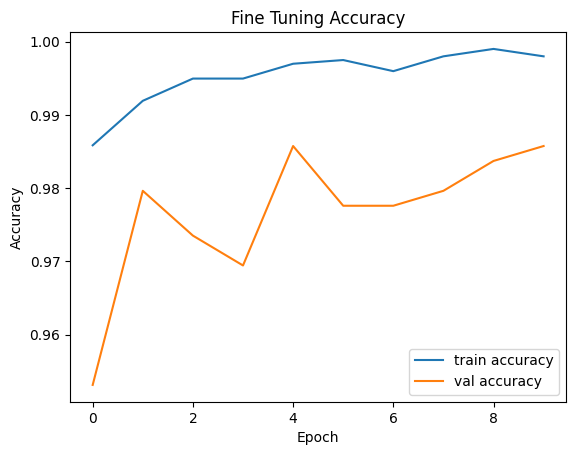

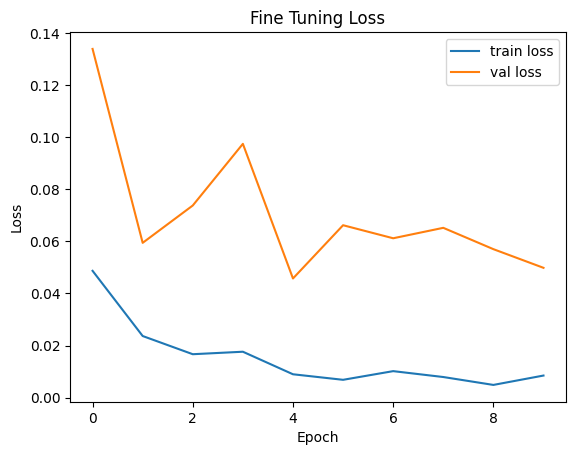

In [13]:
plot_history(history_fine, "Fine Tuning")

Final nga Test Evaluation ug Save.
Gi-evaluate dinhi ang trained model sa test set, gi-print ang final accuracy/loss, ug gi-save ang katapusang trained model file.

In [14]:
test_loss, test_acc = model.evaluate(test_data)
print("Final model test accuracy:", test_acc)
print("Final model test loss:", test_loss)

model.save("mango_classifier.keras")
print("Saved final model: mango_classifier.keras")

44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 522ms/step - accuracy: 0.9686 - loss: 0.0846
Final model test accuracy: 0.9685714244842529
Final model test loss: 0.08460365980863571
Saved final model: mango_classifier.keras


pag-Compare sa Best Checkpoint.
Gi-load dinhi ang best saved checkpoint, gikompara kini sa final trained model gamit ang test set, ug gipili kung unsang model ang angay gamiton para sa deployment.

In [15]:
best_model = tf.keras.models.load_model("best_mango_classifier.keras")
best_test_loss, best_test_acc = best_model.evaluate(test_data)

print("Best checkpoint test accuracy:", best_test_acc)
print("Best checkpoint test loss:", best_test_loss)

if best_test_acc > test_acc:
    deployment_model = best_model
    deployment_name = "mango_classifier_deploy.keras"
    best_model.save(deployment_name)
    print("Using best checkpoint for deployment:", deployment_name)
else:
    deployment_model = model
    deployment_name = "mango_classifier_deploy.keras"
    model.save(deployment_name)
    print("Using final model for deployment:", deployment_name)

44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 463ms/step - accuracy: 0.9686 - loss: 0.0846
Best checkpoint test accuracy: 0.9685714244842529
Best checkpoint test loss: 0.08460365980863571
Using final model for deployment: mango_classifier_deploy.keras


Classification Report ug Confusion Matrix.
Naghimo kini og detalyadong evaluation metrics sama sa precision, recall, F1-score, ug confusion matrix aron makita kung unsa kaayo ka sakto ang prediction sa matag mango class.

44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 528ms/step
              precision    recall  f1-score   support

    Amrapali       1.00      1.00      1.00       140
      Fazlee       1.00      0.95      0.97       140
   Harivanga       0.92      1.00      0.96       140
     Mollika       0.96      0.99      0.97       140
   Nilambori       0.98      0.91      0.94       140

    accuracy                           0.97       700
   macro avg       0.97      0.97      0.97       700
weighted avg       0.97      0.97      0.97       700



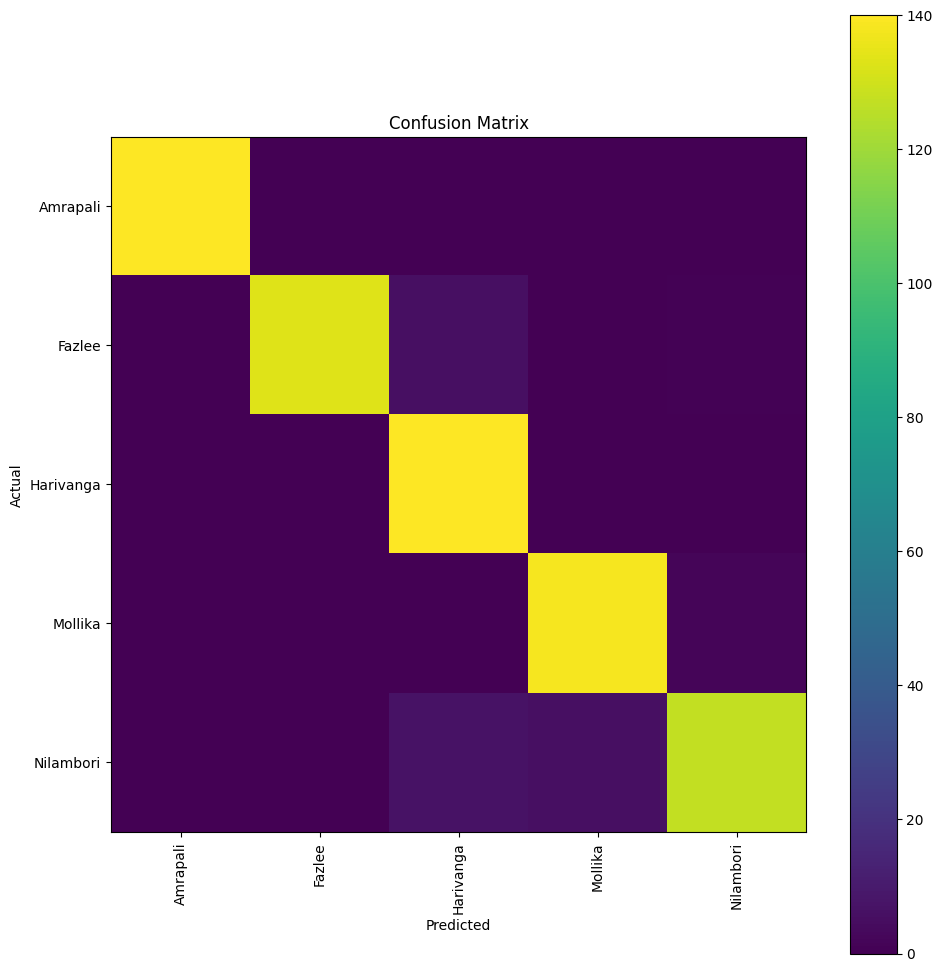

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

test_data.reset()
pred_probs = deployment_model.predict(test_data)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_data.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_data.class_indices.keys()),
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 10))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(train_classes)), train_classes, rotation=90)
plt.yticks(range(len(train_classes)), train_classes)
plt.colorbar()
plt.tight_layout()
plt.show()